<a href="https://colab.research.google.com/github/SANTHOSH-C08/AI-INTERNSHIP/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/titanic.csv')


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [8]:
df["Age"]=df["Age"].fillna(df["Age"].mean())


df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
df['Cabin'] = df['Cabin'].fillna(df['Cabin']).mode()[0]
df['Embarked'] = df['Embarked'].fillna(df['Embarked']).mode()[0]

In [10]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


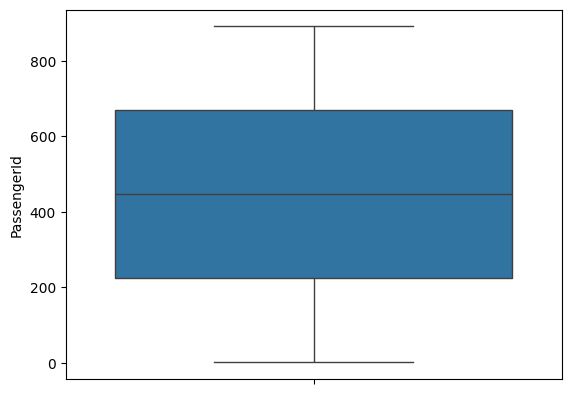

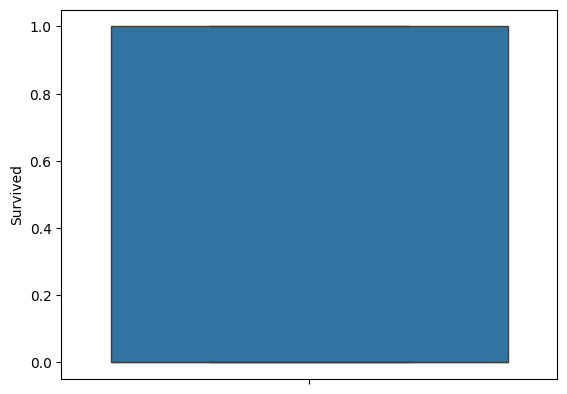

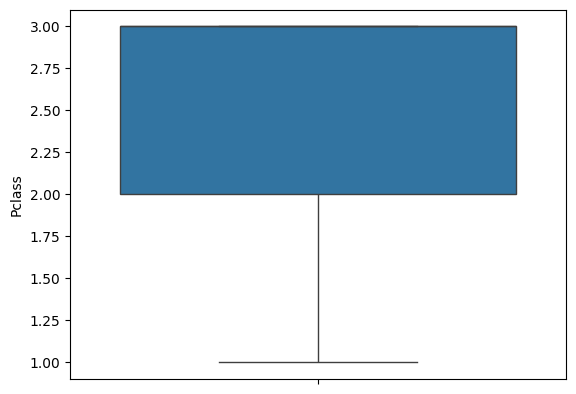

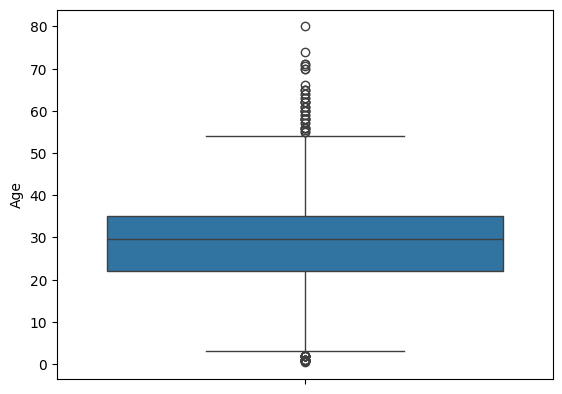

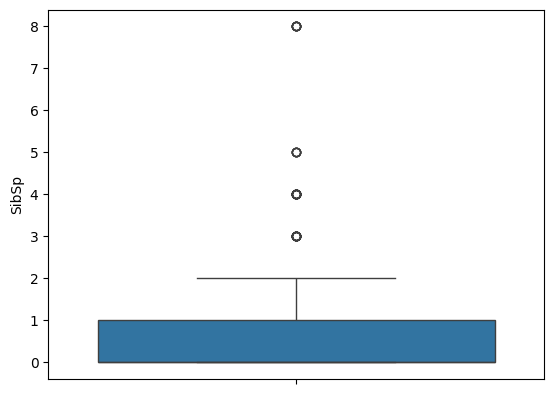

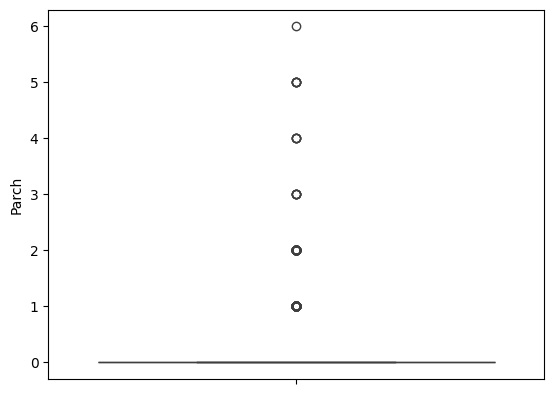

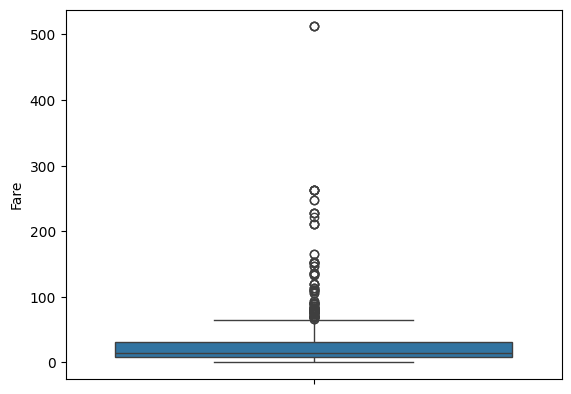

In [11]:
for i in df.columns:
  if df[i].dtypes !="object":
    sns.boxplot(df[i])
    plt.show()

In [12]:
col=['Age','SibSp','Parch','Fare']

In [13]:
for i in col:
  q1=df[i].quantile(0.25)
  q3=df[i].quantile(0.75)
  iqr=q3-q1
  lf=q1-1.5*iqr
  uf=q3+1.5*iqr
  df=df[(lf <= df[i]) & (uf >= df[i])]

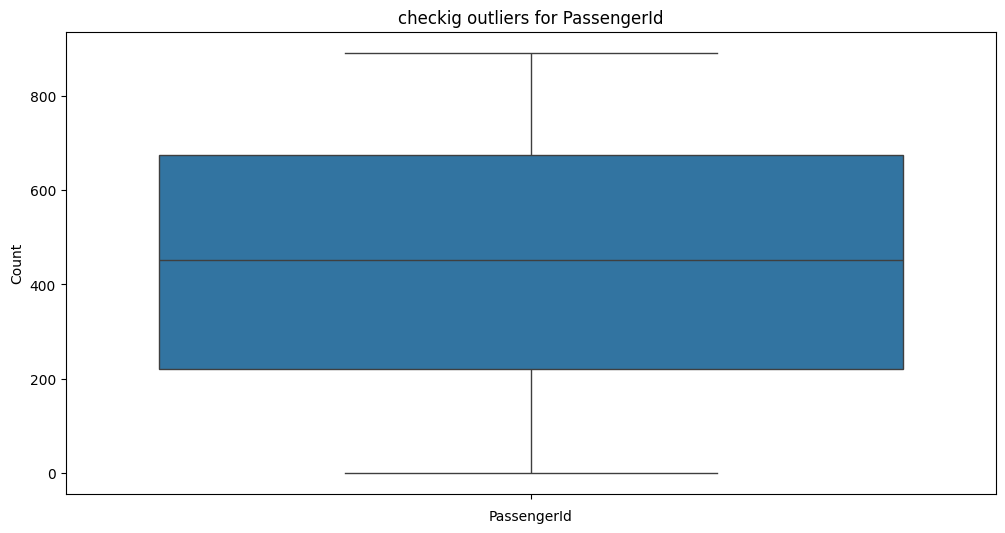

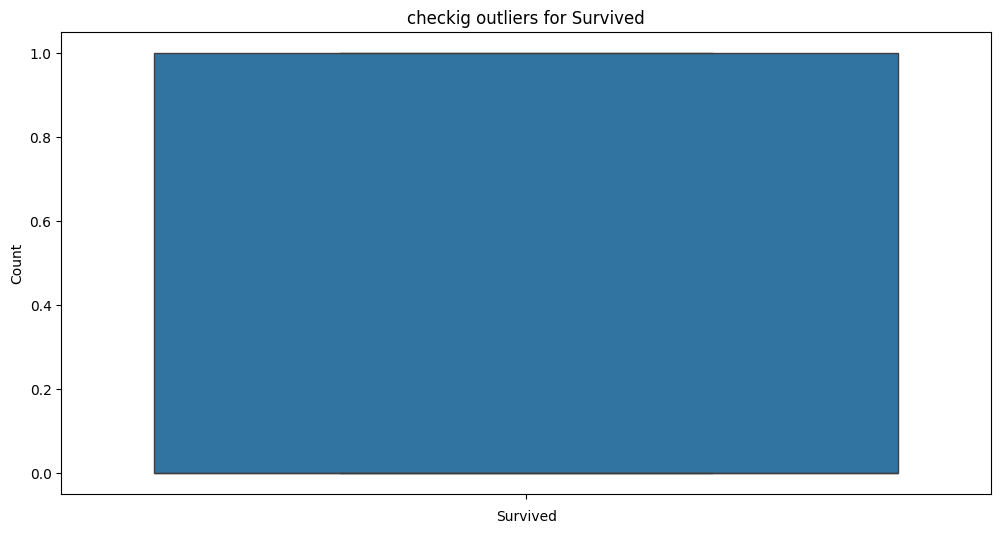

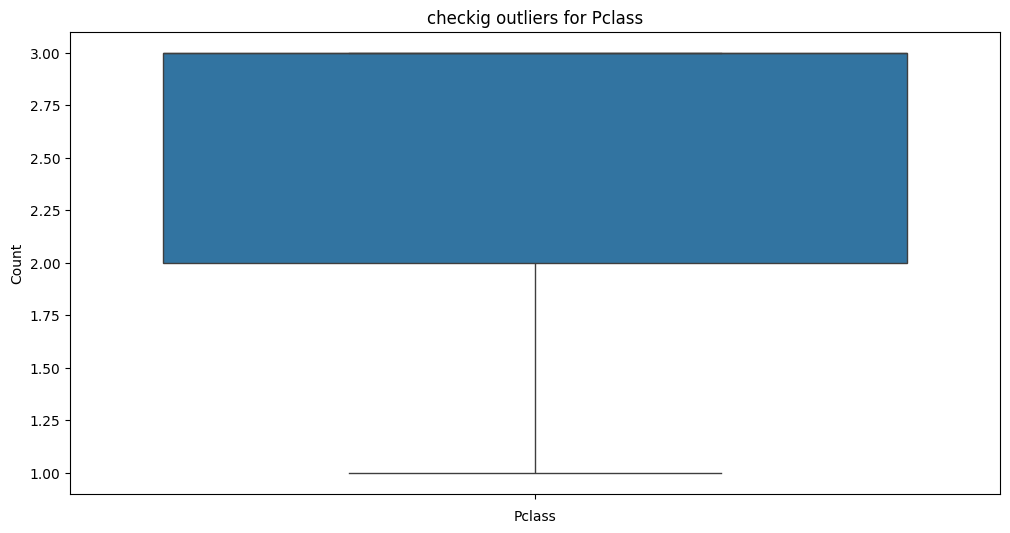

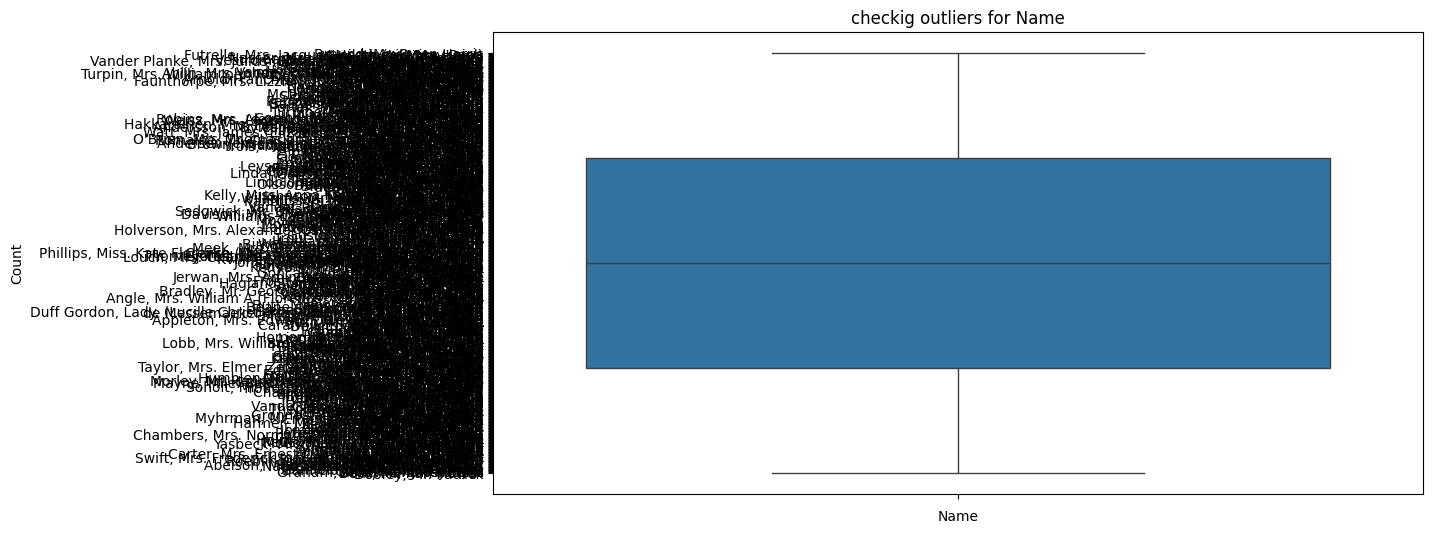

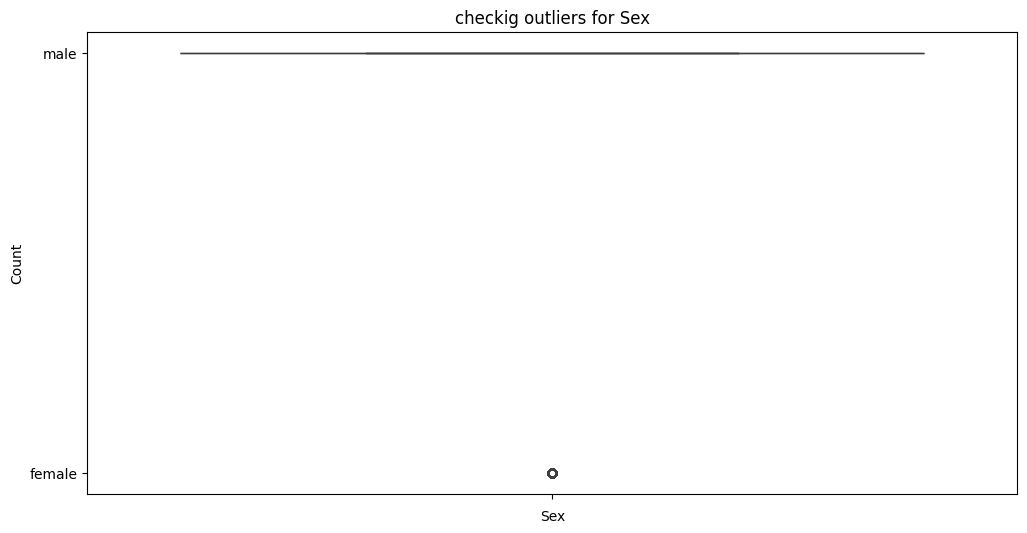

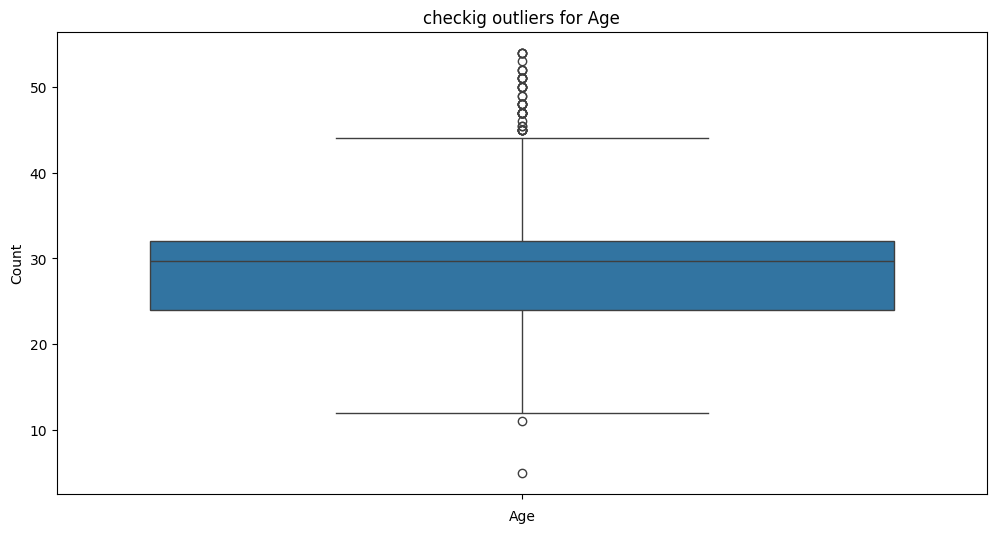

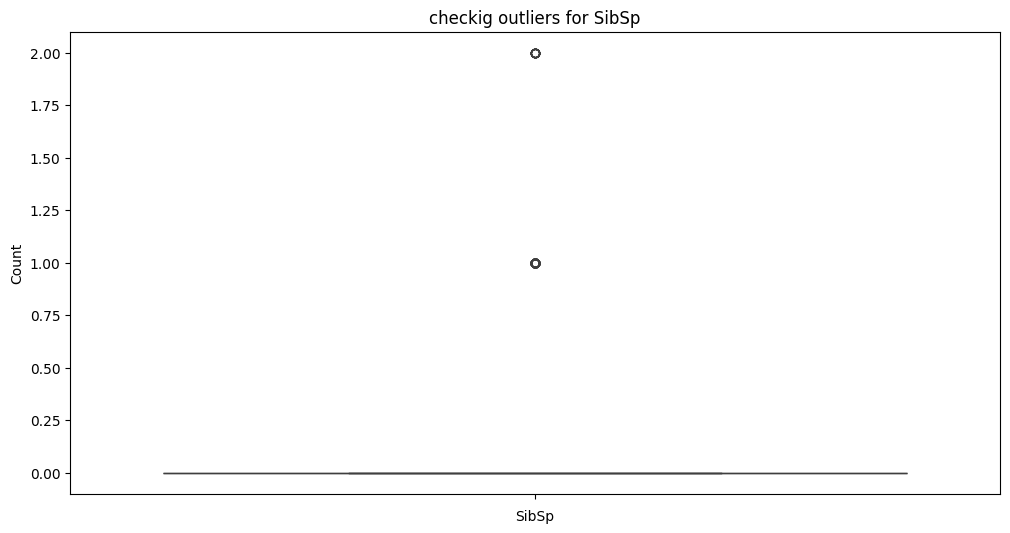

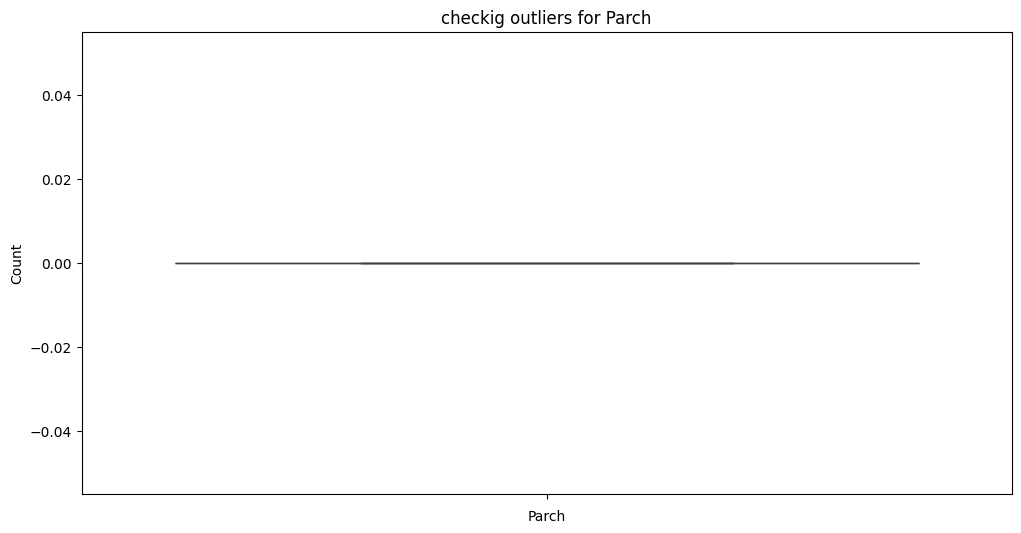

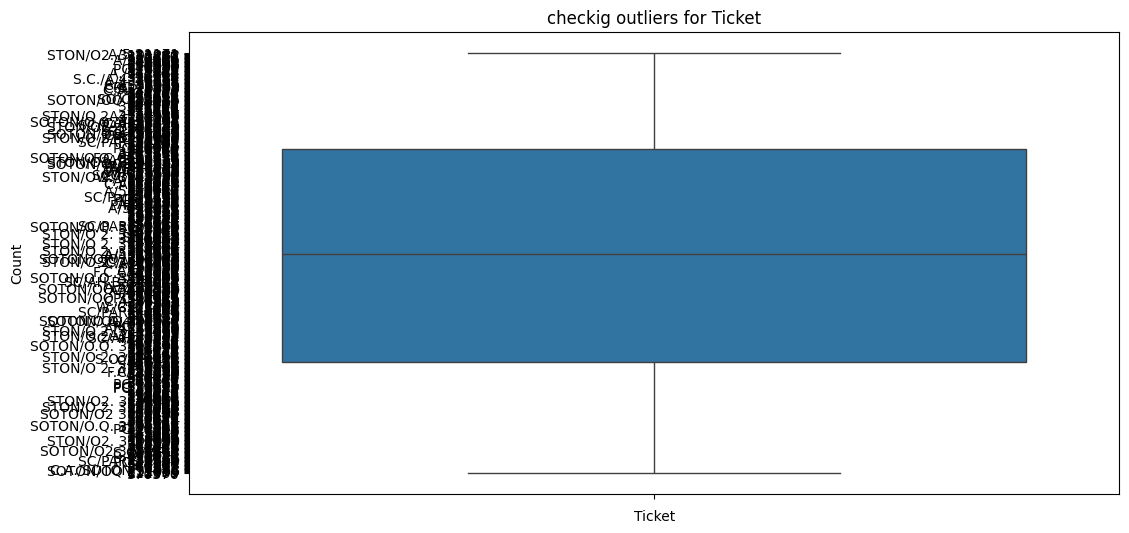

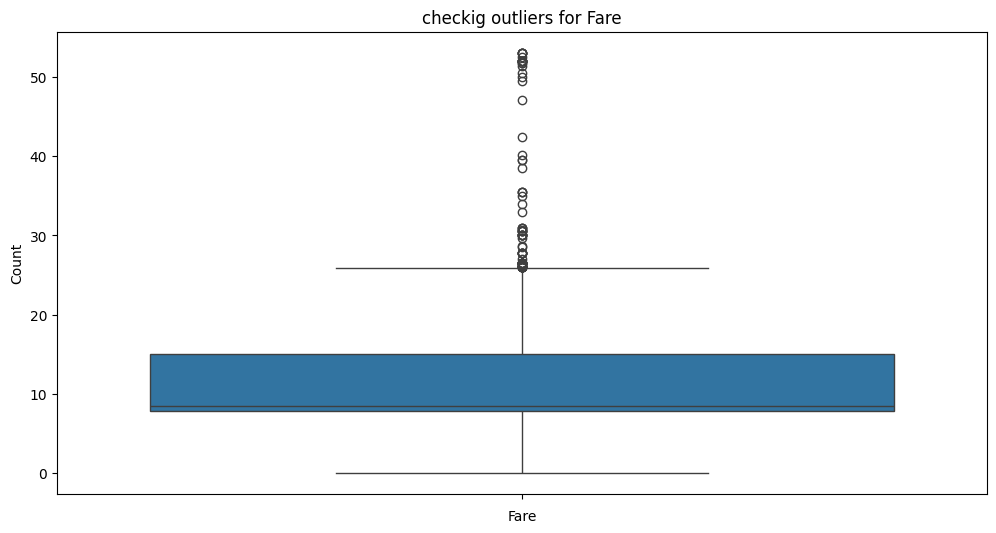

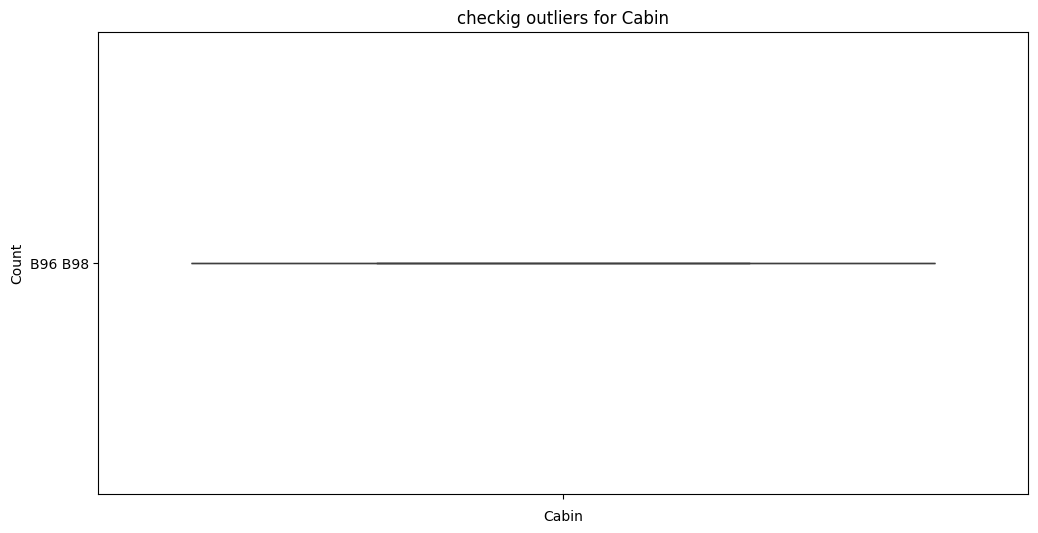

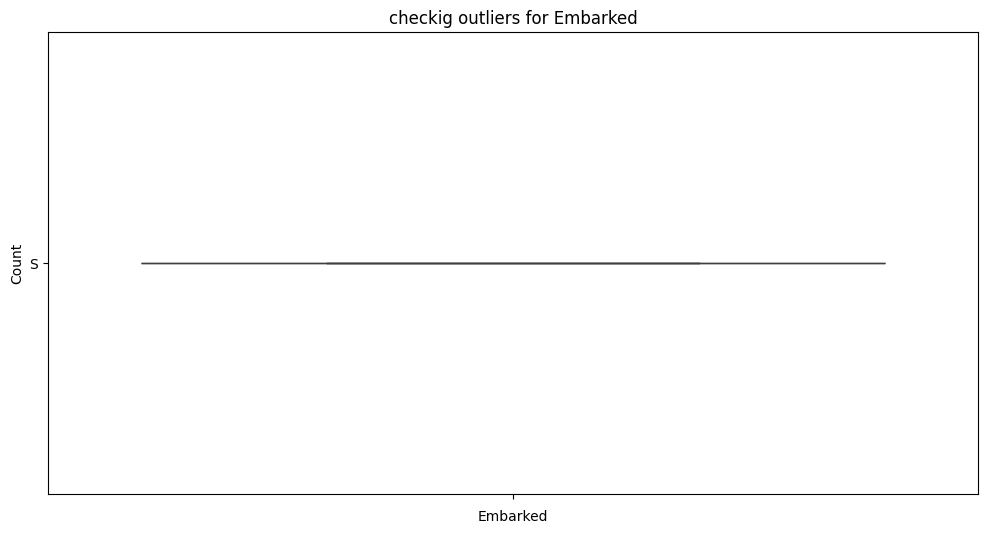

In [14]:
for i in df.columns:
    plt.figure(figsize = (12,6))
    sns.boxplot(df[i])
    plt.title(f"checkig outliers for {i}")
    plt.xlabel(i)
    plt.ylabel("Count")
    plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Name']=le.fit_transform(df['Name'])
df['Sex']=le.fit_transform(df['Sex'])
df['Ticket']=le.fit_transform(df['Ticket'])
df['Cabin']=le.fit_transform(df['Cabin'])
df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,57,1,22.000000,1,0,409,7.2500,0,S
2,3,1,3,205,0,26.000000,0,0,512,7.9250,0,S
3,4,1,1,157,0,35.000000,1,0,32,53.1000,0,S
4,5,0,3,11,1,35.000000,0,0,366,8.0500,0,S
5,6,0,3,345,1,29.699118,0,0,196,8.4583,0,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,496,1,25.000000,0,0,493,7.0500,0,S
886,887,0,2,341,1,27.000000,0,0,59,13.0000,0,S
887,888,1,1,175,0,19.000000,0,0,9,30.0000,0,S
889,890,1,1,42,1,26.000000,0,0,3,30.0000,0,S


In [16]:
x = df.iloc[:,:-1]
y = df[["Survived"]]

In [17]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

In [18]:
x_train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin
740,741,1,1,201,1,29.699118,0,0,48,30.0000,0
0,1,0,3,57,1,22.000000,1,0,409,7.2500,0
19,20,1,3,315,0,29.699118,0,0,125,7.2250,0
460,461,1,1,14,1,48.000000,0,0,54,26.5500,0
36,37,1,3,308,1,29.699118,0,0,138,7.2292,0
...,...,...,...,...,...,...,...,...,...,...,...
110,111,0,1,423,1,47.000000,0,0,0,52.0000,0
163,164,0,3,73,1,17.000000,0,0,187,8.6625,0
431,432,1,3,503,0,29.699118,1,0,370,16.1000,0
704,705,0,3,192,1,26.000000,1,0,306,7.8542,0


In [19]:
from sklearn.ensemble import RandomForestClassifier

In [20]:
model=RandomForestClassifier()
model.fit(x_train, y_train)
y_pred=model.predict(x_test)
print(y_pred)

[0 1 0 0 0 1 0 0 1 1 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 1 0
 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 1 0 1
 1 1 0 1 1 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 0
 0 0]


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [21]:
from sklearn.metrics import accuracy_score
print("Performance of my model:", accuracy_score(y_test, y_pred)*100)


Performance of my model: 100.0
